# Partitioning Analysis

## Setup

In [34]:
from pathlib import Path
import sys, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import QuantileTransformer, StandardScaler

HERE = Path.cwd()
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

from partitioning import _build_partitioner, PARTITIONER_REGISTRY

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(42)

METADATA_CSV = HERE / 'files' / 'train_N28.csv'
N_PARTITIONS = 6
SEED = 42

STRATEGIES = [
    {'name': 'iid', 'cfg': {'type': 'iid', 'n_partitions': N_PARTITIONS, 'mode': 'features'}},
    {'name': 'kmeans', 'cfg': {'type': 'kmeans', 'n_partitions': N_PARTITIONS, 'cluster_share': 0.8, 'dirichlet_alpha': 0.5, 'random_state': SEED}},
    {'name': 'hierarchical', 'cfg': {'type': 'hierarchical', 'n_partitions': N_PARTITIONS, 'cluster_share': 0.8, 'dirichlet_alpha': 0.5, 'random_state': SEED}},
]

print('registry:', list(PARTITIONER_REGISTRY))
print('csv     :', METADATA_CSV)
print('K       :', N_PARTITIONS)

registry: ['iid', 'kmeans', 'hierarchical']
csv     : /home/spedicato/FedCircuitNet/files/train_N28.csv
K       : 6


## Load Metadata

In [35]:
df = pd.read_csv(METADATA_CSV)
print('shape:', df.shape)
df.head()

shape: (7077, 9)


,filename,sample_id,design_name,macro_count,clock,utilization,macro_placement,power_mesh,filler_insertion
0,2187-RISCY-b-1-c2-u0.8-m1-p8-f1,2187,RISCY-b,1,2,0.80,1,8,1
1,5107-RISCY-FPU-a-2-c20-u0.7-m1-p2-f1,5107,RISCY-FPU-a,2,20,0.70,1,2,1
2,1523-RISCY-a-3-c2-u0.75-m2-p5-f1,1523,RISCY-a,3,2,0.75,2,5,1
3,6155-RISCY-FPU-b-1-c5-u0.85-m3-p5-f1,6155,RISCY-FPU-b,1,5,0.85,3,5,1
4,3316-RISCY-b-2-c20-u0.8-m3-p5-f1,3316,RISCY-b,2,20,0.80,3,5,1


In [36]:
META_COLS = [c for c in df.columns if c not in ('filename', 'sample_id')]
summary = pd.DataFrame({
    'dtype': [df[c].dtype for c in META_COLS],
    'n_unique': [df[c].nunique() for c in META_COLS],
    'unique_values': [sorted(df[c].astype(str).unique().tolist()) for c in META_COLS],
})
summary.index.name = 'feature'
summary

,dtype,n_unique,unique_values
feature,,,
0,object,4,"[RISCY-FPU-a, RISCY-FPU-b, RISCY-a, RISCY-b]"
1,int64,3,"[1, 2, 3]"
2,int64,3,"[2, 20, 5]"
3,float64,5,"[0.7, 0.75, 0.8, 0.85, 0.9]"
4,int64,4,"[1, 2, 3, 4]"
5,int64,8,"[1, 2, 3, 4, 5, 6, 7, 8]"
6,int64,2,"[0, 1]"


## Global Metadata Frequency

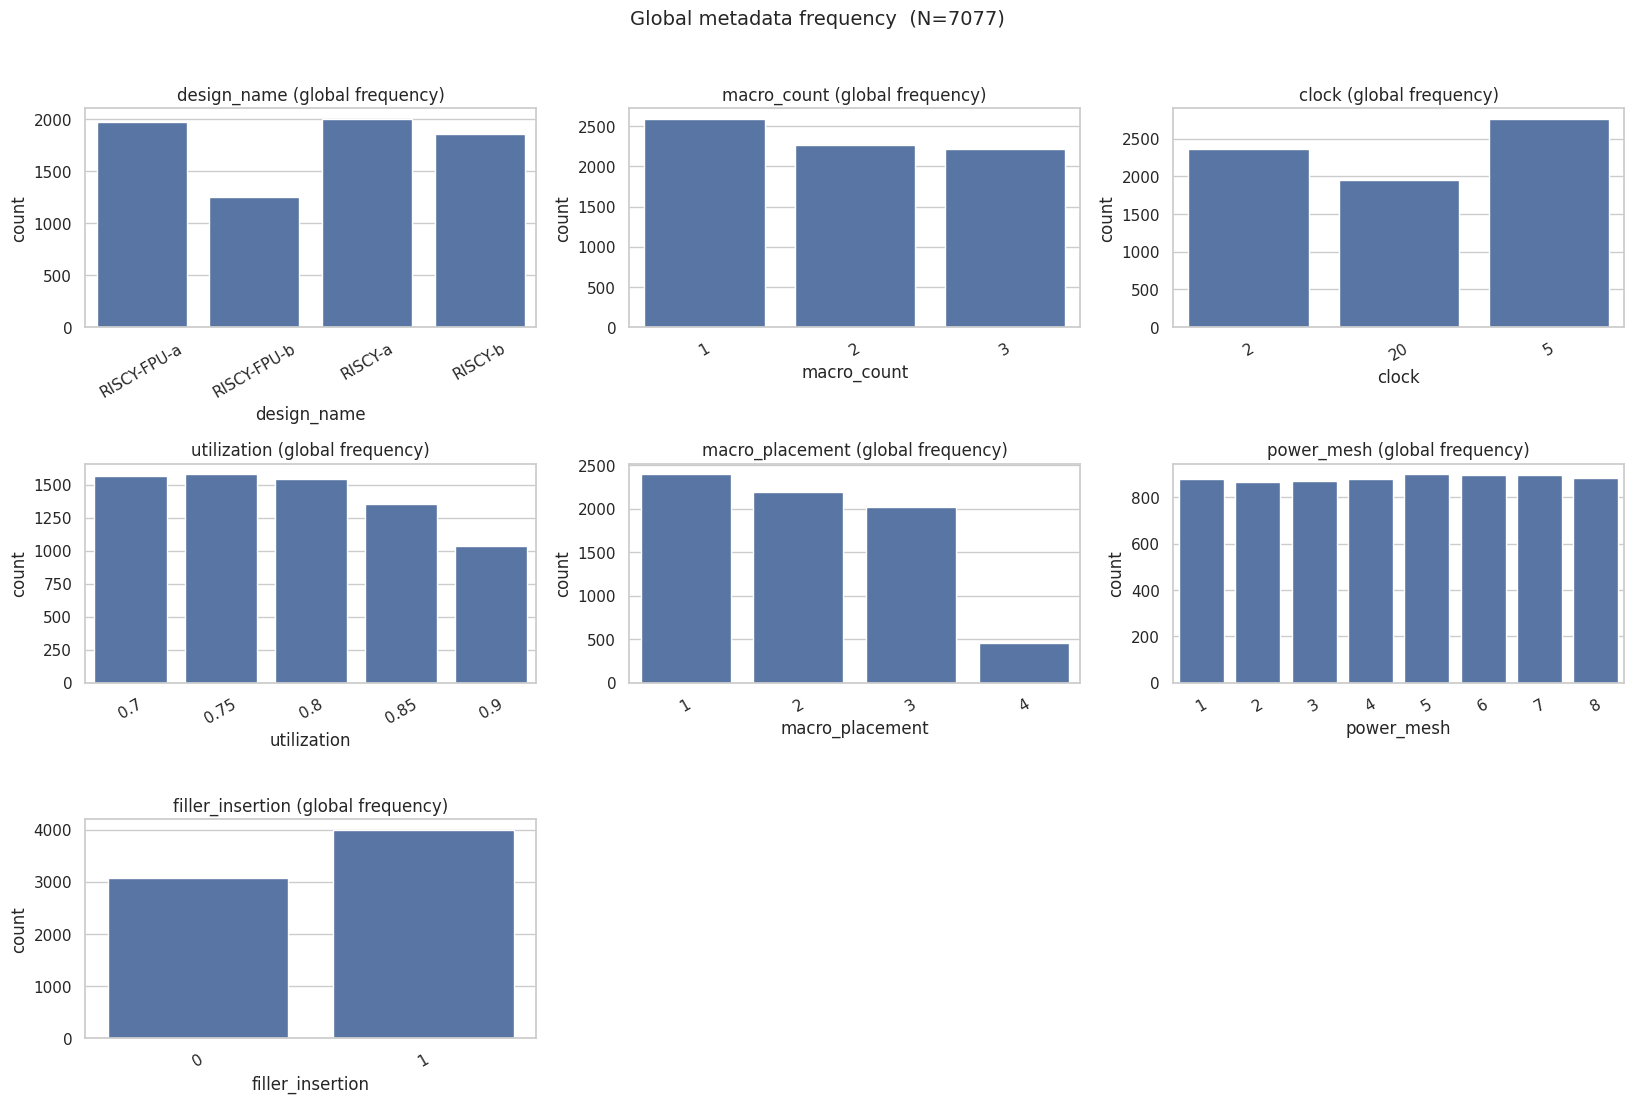

In [37]:
n = len(META_COLS)
cols = 3
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5.5 * cols, 3.6 * rows))
axes = np.array(axes).ravel()
for ax, col in zip(axes, META_COLS):
    vc = df[col].astype(str).value_counts().sort_index()
    sns.barplot(x=vc.index, y=vc.values, ax=ax, color='#4C72B0')
    ax.set_title(f'{col} (global frequency)')
    ax.set_xlabel(col)
    ax.set_ylabel('count')
    ax.tick_params(axis='x', rotation=30)
for ax in axes[n:]:
    ax.set_visible(False)
fig.suptitle(f'Global metadata frequency  (N={len(df)})', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## PCA Projection

In [38]:
sub = df[META_COLS].copy()
cat_cols = [c for c in META_COLS if not pd.api.types.is_numeric_dtype(sub[c])]
if cat_cols:
    sub = pd.get_dummies(sub, columns=cat_cols, dtype='uint8')
X = sub.to_numpy(dtype=float)
X = QuantileTransformer(output_distribution='normal', n_quantiles=min(1000, len(X)), random_state=SEED).fit_transform(X)
X = StandardScaler().fit_transform(X)
pca = PCA(n_components=min(X.shape), random_state=SEED)
Z = pca.fit_transform(X)
evr = pca.explained_variance_ratio_
print(f'PCA components: {Z.shape[1]}  PC1={evr[0]:.3f}  PC2={evr[1]:.3f}  PC3={evr[2]:.3f}')
print(f'cumulative(first 5): {np.cumsum(evr)[:5].round(3)}')

PCA components: 10  PC1=0.150  PC2=0.139  PC3=0.134
cumulative(first 5): [0.15  0.289 0.422 0.527 0.63 ]


## Run Partitioners

In [53]:
def build_assignment(parts):
    assignment = np.full(len(df), -1, dtype=int)
    lookup = {name: i for i, name in enumerate(df['filename'].to_numpy())}
    for i, p in enumerate(parts):
        for name in p['filename']:
            assignment[lookup[name]] = i
    return assignment


results = {}
for entry in STRATEGIES:
    part = _build_partitioner(dict(entry['cfg']))
    parts = part.partition(df)
    results[entry['name']] = {
        'partitioner': part,
        'parts': parts,
        'assignment': build_assignment(parts),
        'sizes': [len(p) for p in parts],
    }
    print(f"{entry['name']:14s}  cls={part.__class__.__name__:24s}  sizes={results[entry['name']]['sizes']} Total={sum(results[entry['name']]['sizes'])}  n_parts={len(parts)}")

STRAT_NAMES = list(results)

iid             cls=IIDPartitioner            sizes=[1180, 1180, 1180, 1179, 1179, 1179] Total=7077  n_parts=6


kmeans          cls=KMeansClustering          sizes=[1312, 1711, 892, 796, 1271, 1095] Total=7077  n_parts=6
hierarchical    cls=HierarchicalClustering    sizes=[1193, 925, 914, 1176, 1228, 1641] Total=7077  n_parts=6


## Partition Size Comparison

In [40]:
sizes_df = pd.DataFrame({name: results[name]['sizes'] for name in STRAT_NAMES},
                        index=[f'P{i}' for i in range(N_PARTITIONS)])
sizes_df.loc['TOTAL'] = sizes_df.sum()
sizes_df.loc['MIN'] = sizes_df.iloc[:N_PARTITIONS].min()
sizes_df.loc['MAX'] = sizes_df.iloc[:N_PARTITIONS].max()
sizes_df.loc['STD'] = sizes_df.iloc[:N_PARTITIONS].std().round(1)
sizes_df

,iid,kmeans,hierarchical
P0,1180.0,1312.0,1193.0
P1,1180.0,1711.0,925.0
P2,1180.0,892.0,914.0
P3,1179.0,796.0,1176.0
P4,1179.0,1271.0,1228.0
P5,1179.0,1095.0,1641.0
TOTAL,7077.0,7077.0,7077.0
MIN,1179.0,796.0,914.0
MAX,1180.0,1711.0,1641.0
STD,0.5,330.2,264.9


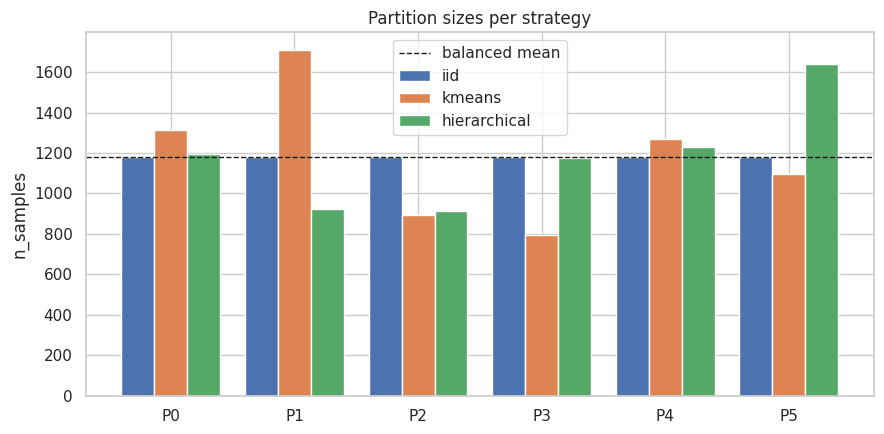

In [41]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(N_PARTITIONS)
width = 0.8 / len(STRAT_NAMES)
palette = sns.color_palette('deep', len(STRAT_NAMES))
for i, name in enumerate(STRAT_NAMES):
    ax.bar(x + (i - (len(STRAT_NAMES) - 1) / 2) * width,
           results[name]['sizes'], width, label=name, color=palette[i])
ax.set_xticks(x)
ax.set_xticklabels([f'P{i}' for i in range(N_PARTITIONS)])
ax.set_ylabel('n_samples')
ax.set_title('Partition sizes per strategy')
ax.axhline(len(df) / N_PARTITIONS, ls='--', color='k', lw=1, label='balanced mean')
ax.legend()
fig.tight_layout()
plt.show()

## PCA Scatter Colored by Partition

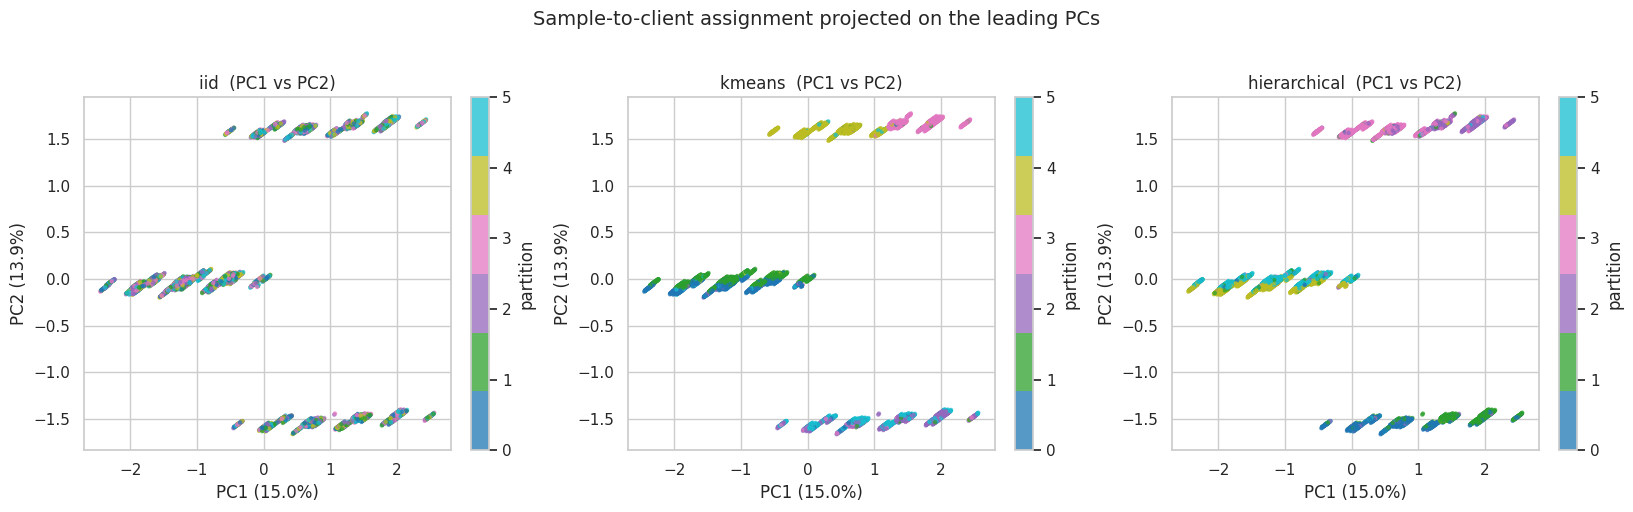

In [42]:
fig, axes = plt.subplots(1, len(STRAT_NAMES), figsize=(5.5 * len(STRAT_NAMES), 5), squeeze=False)
cmap = plt.get_cmap('tab10', N_PARTITIONS)
for ax, name in zip(axes[0], STRAT_NAMES):
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=results[name]['assignment'],
                    cmap=cmap, vmin=0, vmax=N_PARTITIONS - 1,
                    s=10, alpha=0.75, edgecolor='none')
    ax.set_title(f'{name}  (PC1 vs PC2)')
    ax.set_xlabel(f'PC1 ({evr[0] * 100:.1f}%)')
    ax.set_ylabel(f'PC2 ({evr[1] * 100:.1f}%)')
    cbar = plt.colorbar(sc, ax=ax, ticks=range(N_PARTITIONS), fraction=0.045)
    cbar.set_label('partition')
fig.suptitle('Sample-to-client assignment projected on the leading PCs', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## Per-Partition Composition

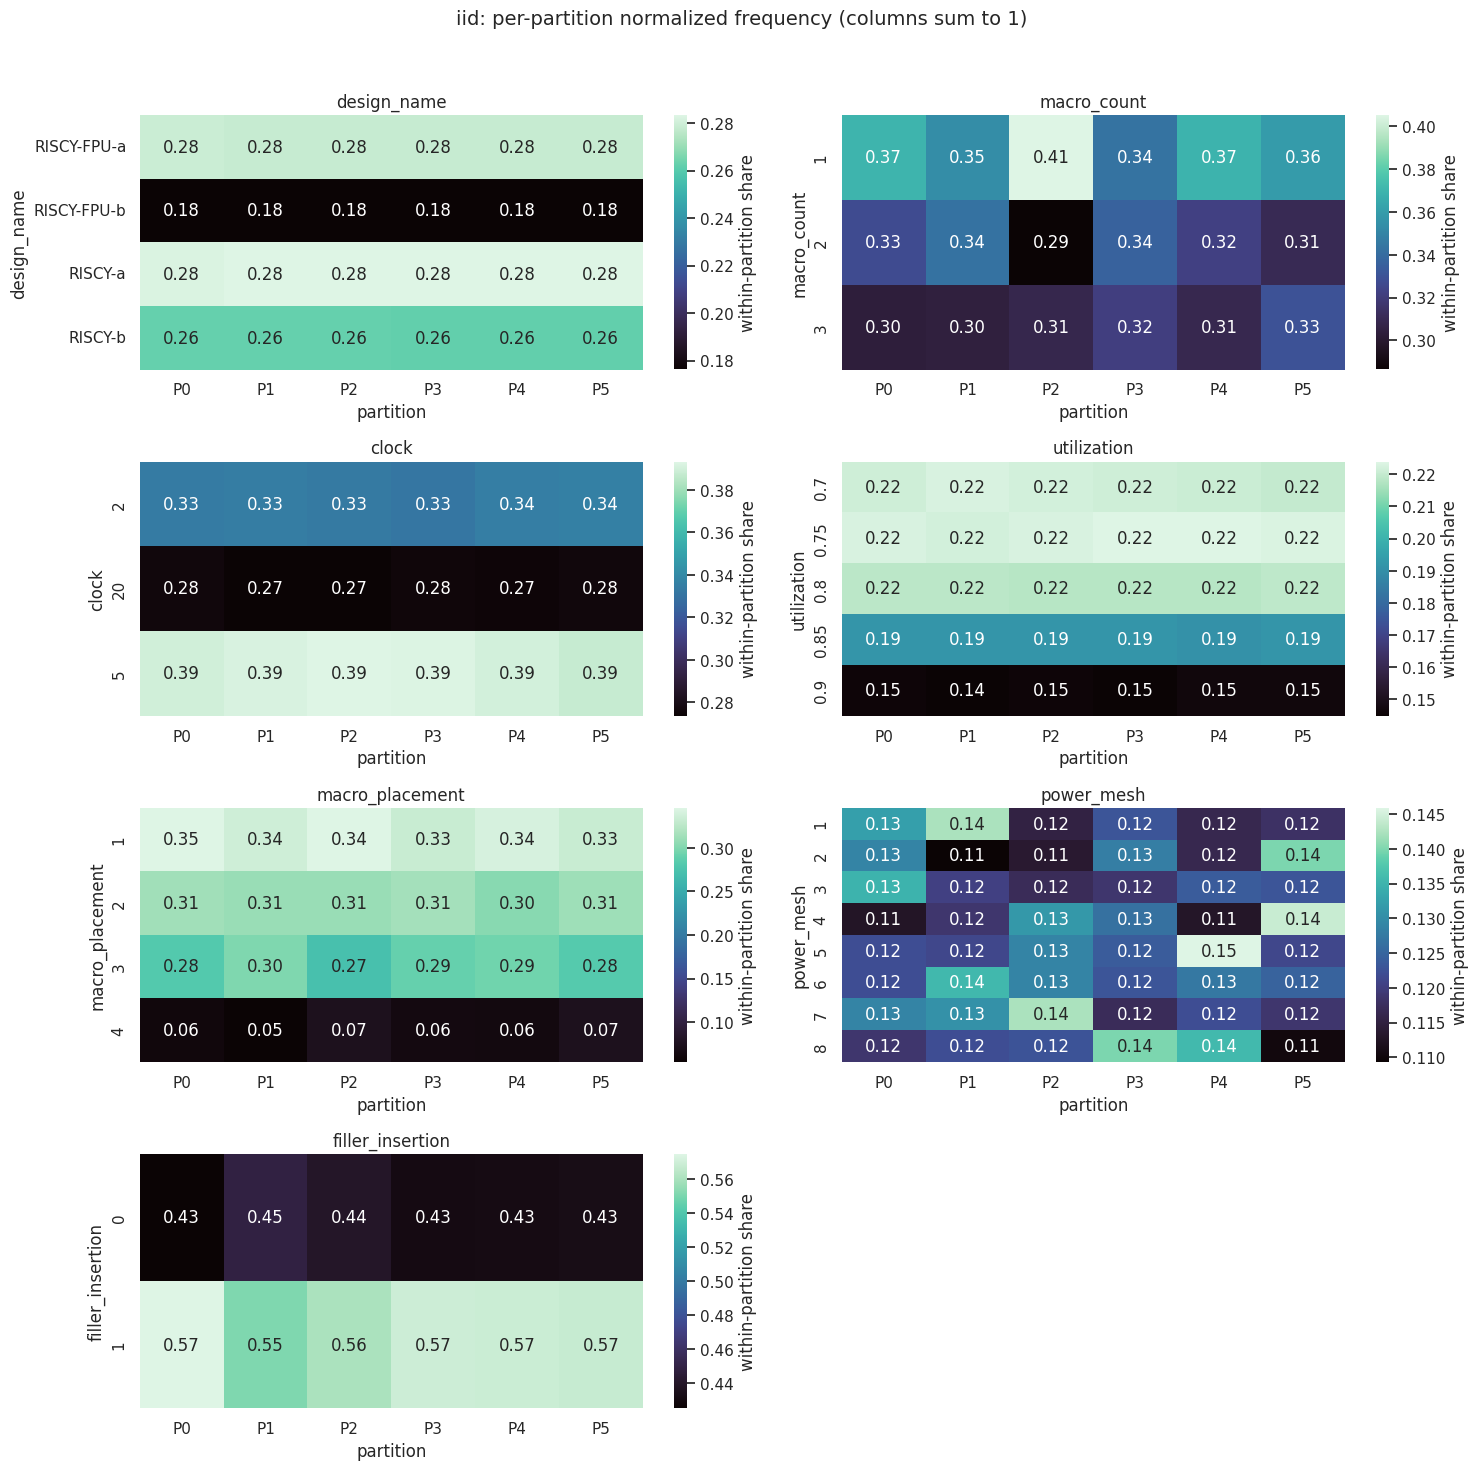

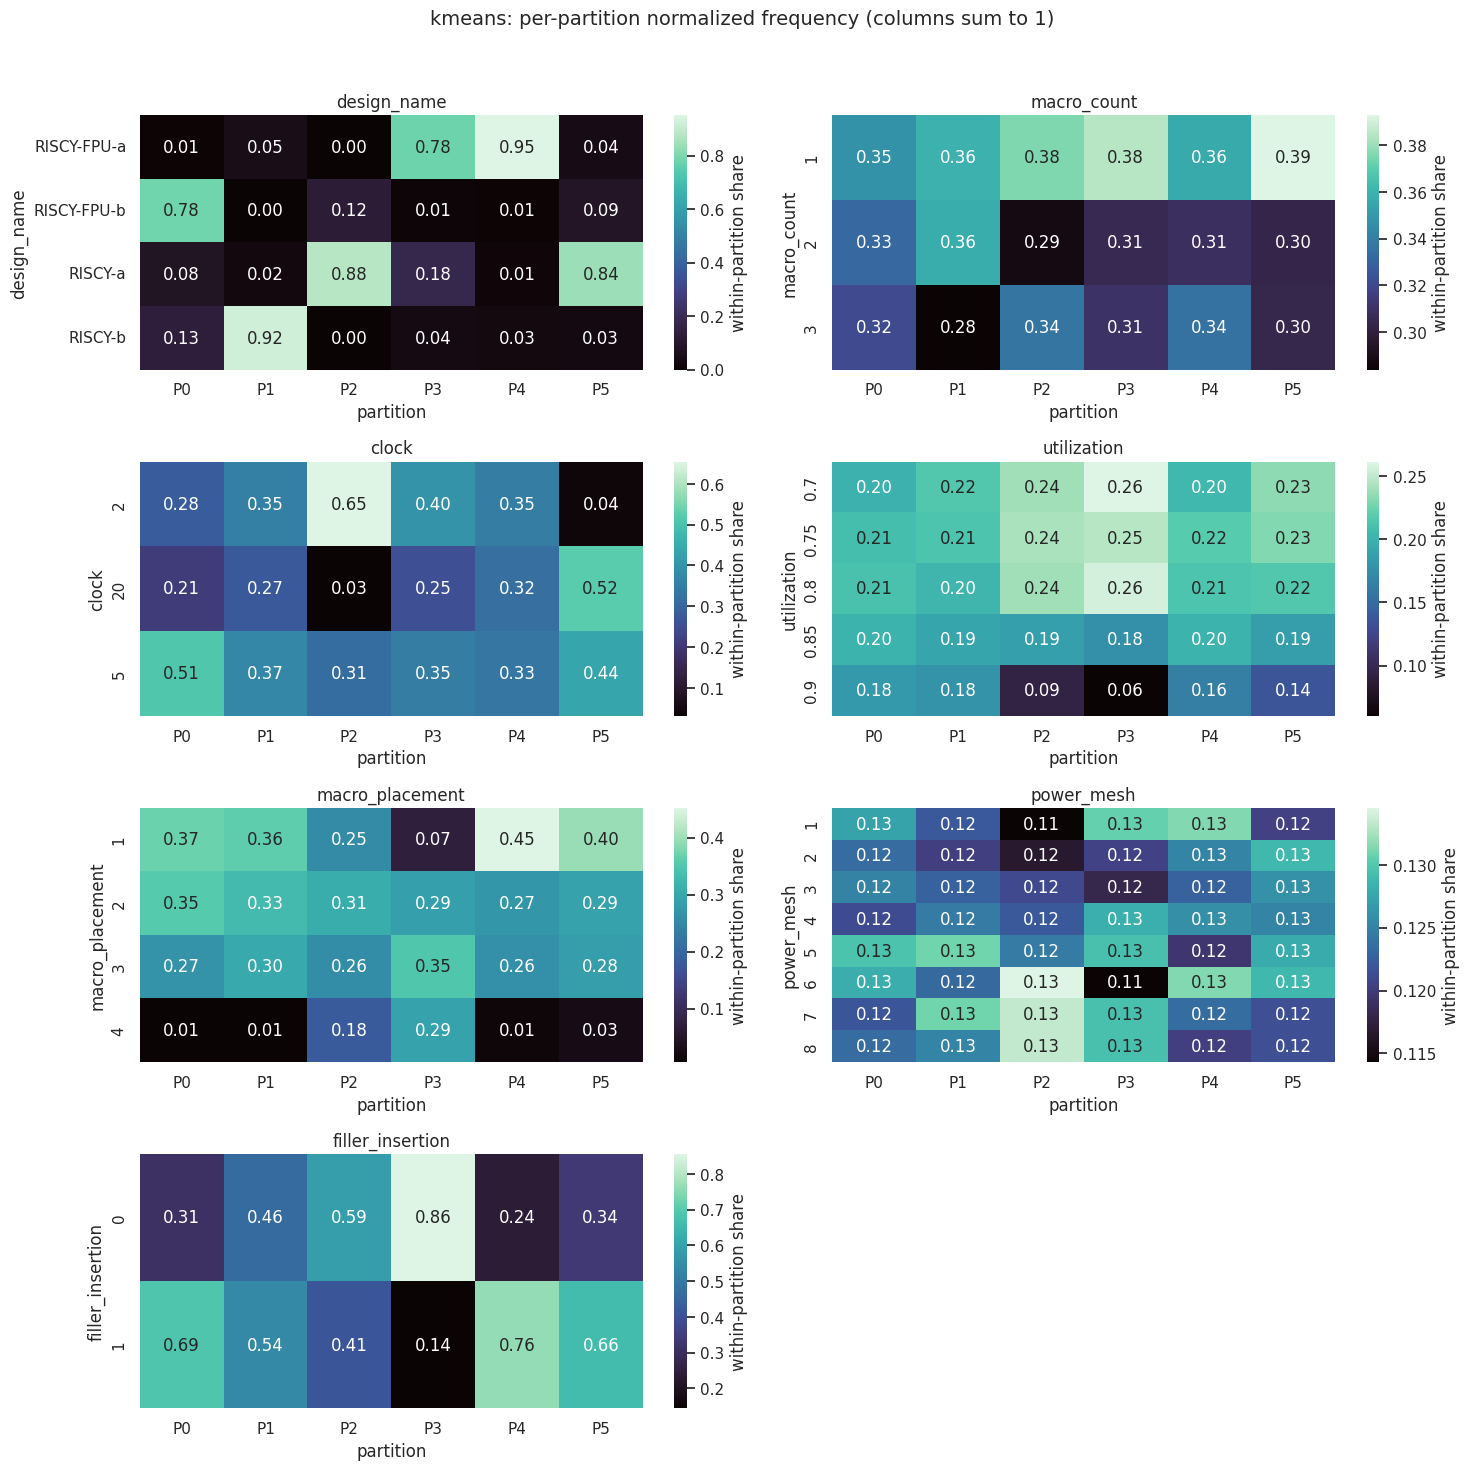

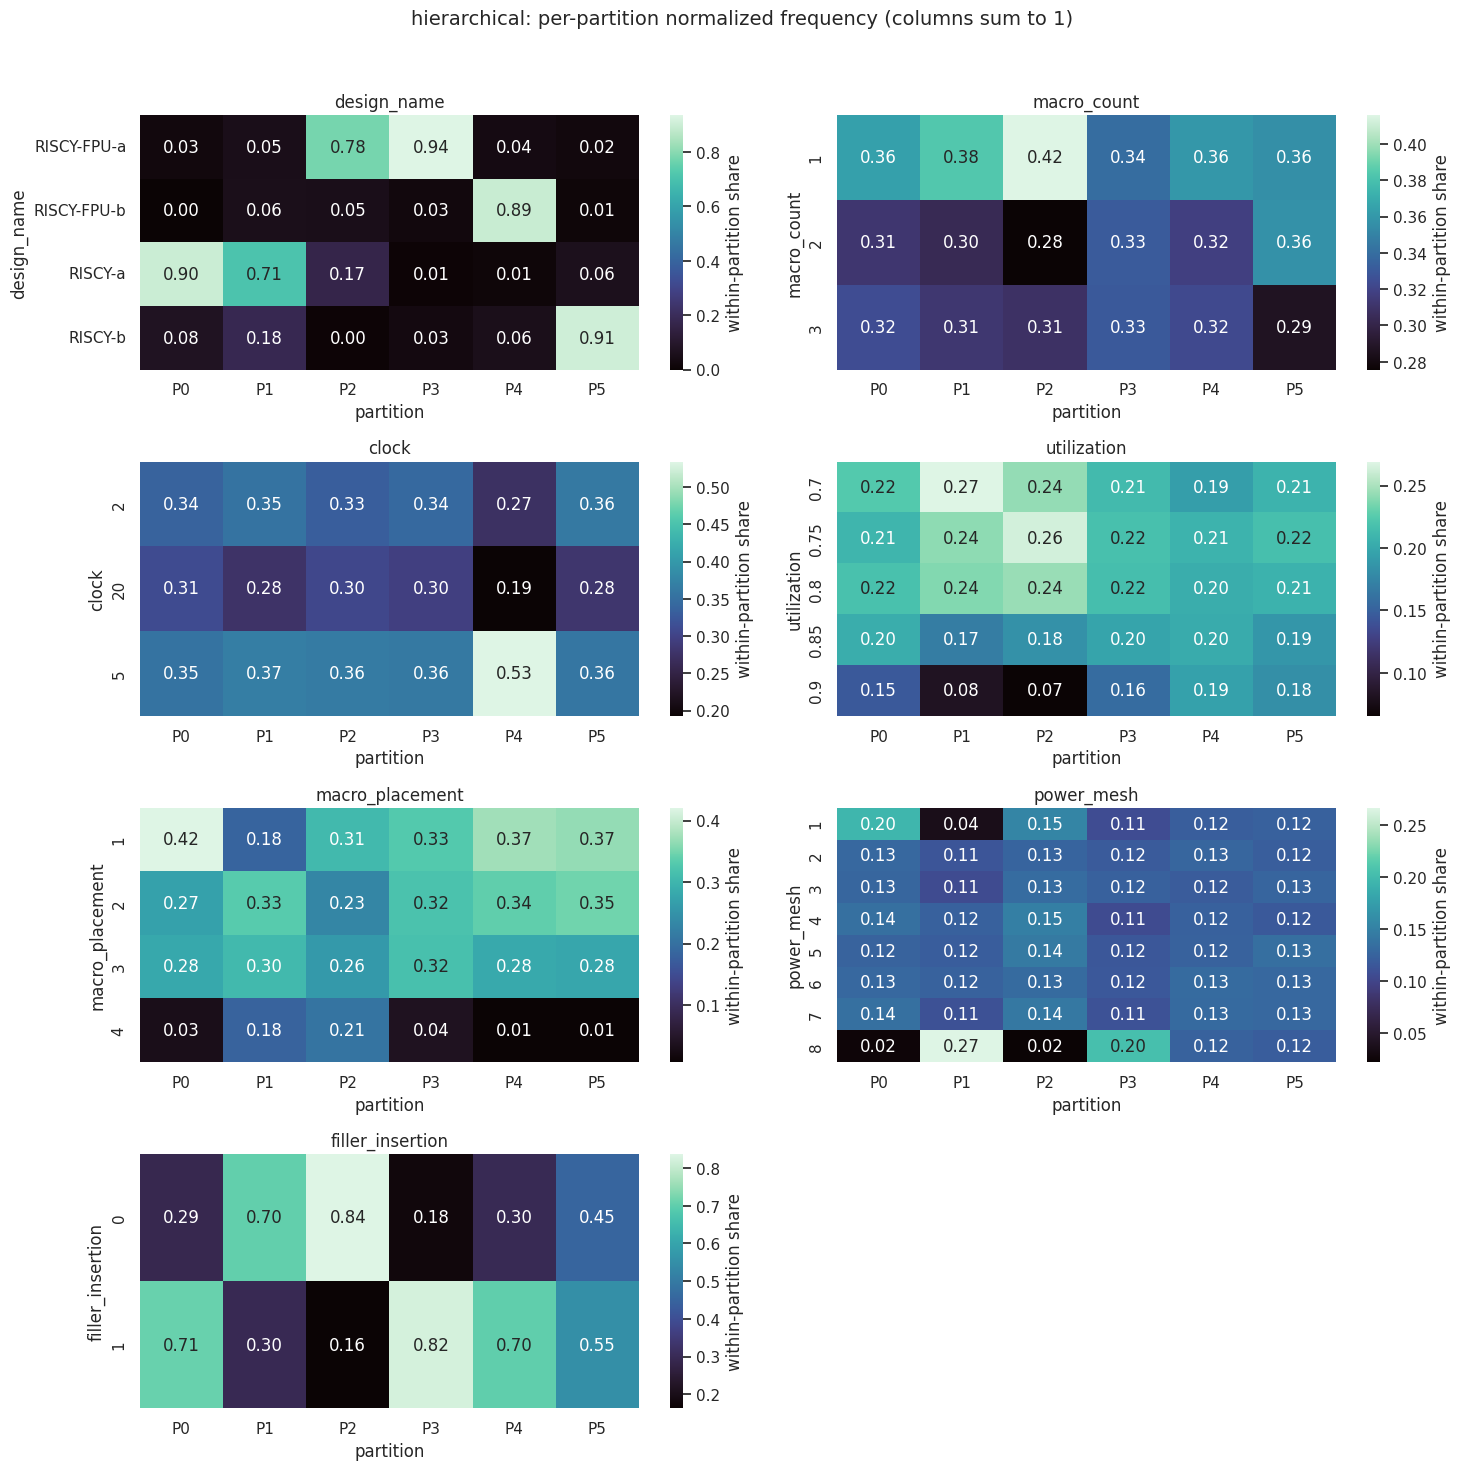

In [43]:
def per_partition_counts(parts, col):
    vals = sorted(df[col].astype(str).unique().tolist())
    return pd.DataFrame(
        {f'P{i}': p[col].astype(str).value_counts().reindex(vals, fill_value=0)
         for i, p in enumerate(parts)},
        index=vals,
    )


for name in STRAT_NAMES:
    parts = results[name]['parts']
    n = len(META_COLS)
    cols = 2
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(7.5 * cols, 3.6 * rows))
    axes = np.array(axes).ravel()
    for ax, col in zip(axes, META_COLS):
        mat = per_partition_counts(parts, col)
        share = mat.div(mat.sum(axis=0), axis=1).fillna(0.0)
        sns.heatmap(share, annot=True, fmt='.2f', cmap='mako', ax=ax,
                    cbar_kws={'label': 'within-partition share'})
        ax.set_title(f'{col}')
        ax.set_xlabel('partition')
        ax.set_ylabel(col)
    for ax in axes[n:]:
        ax.set_visible(False)
    fig.suptitle(f'{name}: per-partition normalized frequency (columns sum to 1)', fontsize=14, y=1.02)
    fig.tight_layout()
    plt.show()

## JS Divergence vs Global

In [44]:
def js_divergence(p, q, eps=1e-12):
    p = np.asarray(p, dtype=float) + eps
    q = np.asarray(q, dtype=float) + eps
    p /= p.sum()
    q /= q.sum()
    m = 0.5 * (p + q)
    kl = lambda a, b: np.sum(a * np.log2(a / b))
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)


def js_table(parts):
    rows = {}
    for col in META_COLS:
        global_vc = df[col].astype(str).value_counts()
        vals = global_vc.index
        g = global_vc.reindex(vals, fill_value=0).to_numpy()
        rows[col] = [
            js_divergence(p[col].astype(str).value_counts().reindex(vals, fill_value=0).to_numpy(), g)
            for p in parts
        ]
    tbl = pd.DataFrame(rows, index=[f'P{i}' for i in range(len(parts))]).T
    tbl['mean'] = tbl.mean(axis=1)
    return tbl


for name in STRAT_NAMES:
    results[name]['js'] = js_table(results[name]['parts'])

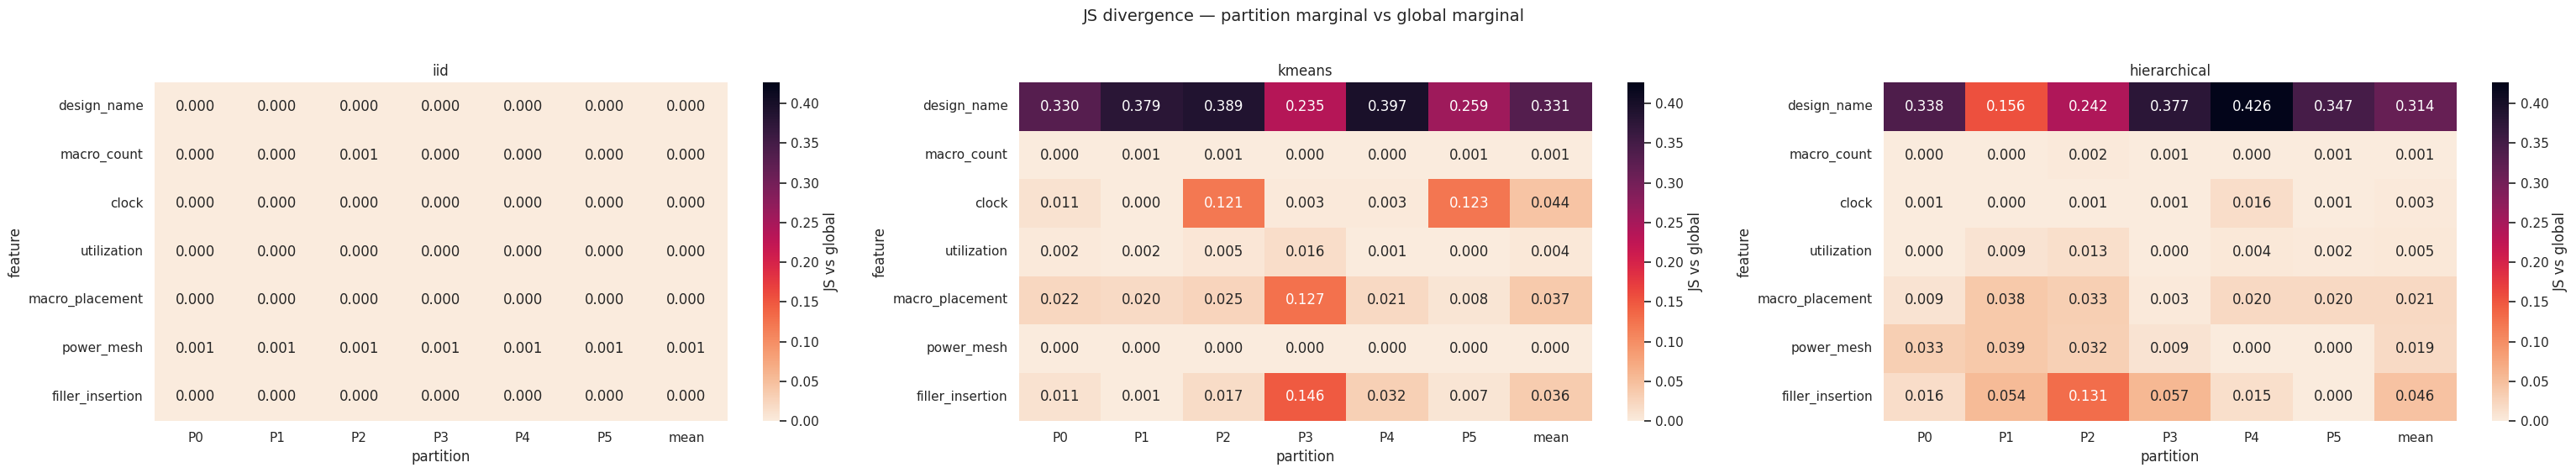

In [45]:
fig, axes = plt.subplots(1, len(STRAT_NAMES),
                         figsize=(1.3 * (N_PARTITIONS + 2) * len(STRAT_NAMES), 0.5 * len(META_COLS) + 2),
                         squeeze=False)
vmax = max(results[n]['js'].to_numpy().max() for n in STRAT_NAMES)
for ax, name in zip(axes[0], STRAT_NAMES):
    sns.heatmap(results[name]['js'], annot=True, fmt='.3f', cmap='rocket_r',
                vmin=0, vmax=vmax, ax=ax,
                cbar_kws={'label': 'JS vs global'})
    ax.set_title(f'{name}')
    ax.set_xlabel('partition')
    ax.set_ylabel('feature')
fig.suptitle('JS divergence — partition marginal vs global marginal', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

In [46]:
mean_js = pd.DataFrame(
    {name: results[name]['js']['mean'] for name in STRAT_NAMES}
)
mean_js.loc['OVERALL'] = mean_js.mean()
mean_js.round(4)

,iid,kmeans,hierarchical
design_name,0.0000,0.3314,0.3142
macro_count,0.0004,0.0006,0.0008
clock,0.0000,0.0436,0.0033
utilization,0.0000,0.0043,0.0048
macro_placement,0.0002,0.0372,0.0206
power_mesh,0.0009,0.0002,0.0187
filler_insertion,0.0000,0.0357,0.0456
OVERALL,0.0002,0.0647,0.0583


## Coverage Table

In [47]:
coverage_frames = []
for name in STRAT_NAMES:
    rows = []
    for i, p in enumerate(results[name]['parts']):
        row = {'strategy': name, 'partition': f'P{i}', 'n_samples': len(p)}
        for col in META_COLS:
            row[f'unique_{col}'] = p[col].nunique()
        rows.append(row)
    coverage_frames.append(pd.DataFrame(rows))
coverage = pd.concat(coverage_frames, ignore_index=True).set_index(['strategy', 'partition'])
coverage

n_samples  unique_design_name  unique_macro_count  \
strategy     partition                                                      
iid          P0              1180                   4                   3   
             P1              1180                   4                   3   
             P2              1180                   4                   3   
             P3              1179                   4                   3   
             P4              1179                   4                   3   
             P5              1179                   4                   3   
kmeans       P0              1312                   4                   3   
             P1              1711                   4                   3   
             P2               892                   2                   3   
             P3               796                   4                   3   
             P4              1271                   4                   3   
             P5              1095                   4                   3   
hierarchical P0              1193                   3                   3   
             P1               925                   4                   3   
             P2               914                   4                   3   
             P3              1176                   4                   3   
             P4              1228                   4                   3   
             P5              1641                   4                   3   

                        unique_clock  unique_utilization  \
strategy     partition                                     
iid          P0                    3                   5   
             P1                    3                   5   
             P2                    3                   5   
             P3                    3                   5   
             P4                    3                   5   
             P5                    3                   5   
kmeans       P0                    3                   5   
             P1                    3                   5   
             P2                    3                   5   
             P3                    3                   5   
             P4                    3                   5   
             P5                    3                   5   
hierarchical P0                    3                   5   
             P1                    3                   5   
             P2                    3                   5   
             P3                    3                   5   
             P4                    3                   5   
             P5                    3                   5   

                        unique_macro_placement  unique_power_mesh  \
strategy     partition                                              
iid          P0                              4                  8   
             P1                              4                  8   
             P2                              4                  8   
             P3                              4                  8   
             P4                              4                  8   
             P5                              4                  8   
kmeans       P0                              4                  8   
             P1                              4                  8   
             P2                              4                  8   
             P3                              4                  8   
             P4                              4                  8   
             P5                              4                  8   
hierarchical P0                              4                  8   
             P1                              4                  8   
             P2                              4                  8   
             P3                              4                  8   
             P4                         

## Cluster / Partition Overlap

In [48]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

assign_iid = results['iid']['assignment']
rows = []
for name in STRAT_NAMES:
    a = results[name]['assignment']
    row = {'strategy': name, 'ARI_vs_iid': adjusted_rand_score(assign_iid, a),
           'NMI_vs_iid': normalized_mutual_info_score(assign_iid, a)}
    for col in META_COLS:
        y = df[col].astype(str).to_numpy()
        row[f'ARI[{col}]'] = adjusted_rand_score(y, a)
    rows.append(row)
overlap = pd.DataFrame(rows).set_index('strategy').round(3)
overlap

,ARI_vs_iid,NMI_vs_iid,ARI[design_name],ARI[macro_count],ARI[clock],ARI[utilization],ARI[macro_placement],ARI[power_mesh],ARI[filler_insertion]
strategy,,,,,,,,,
iid,1.0,1.000,-0.001,0.000,-0.000,-0.001,-0.000,0.000,-0.000
kmeans,-0.0,0.000,0.541,0.001,0.036,0.000,0.026,-0.001,0.040
hierarchical,-0.0,0.001,0.532,0.001,0.006,0.001,0.016,0.010,0.058


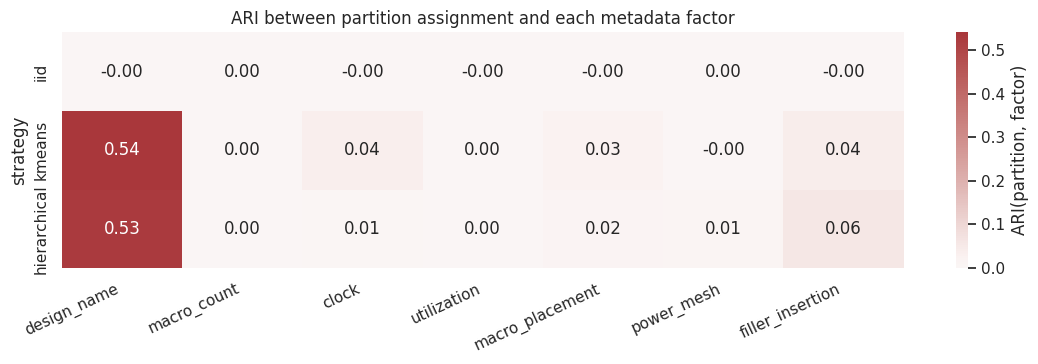

In [49]:
ari_cols = [c for c in overlap.columns if c.startswith('ARI[')]
fig, ax = plt.subplots(figsize=(1.2 * len(ari_cols) + 3, 0.6 * len(STRAT_NAMES) + 2))
sns.heatmap(overlap[ari_cols], annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax,
            cbar_kws={'label': 'ARI(partition, factor)'})
ax.set_title('ARI between partition assignment and each metadata factor')
ax.set_xticklabels([c[4:-1] for c in ari_cols], rotation=25, ha='right')
ax.set_ylabel('strategy')
fig.tight_layout()
plt.show()